# Pytorch

# Основы PyTorch и работы с GPU

## 1.1 Тензоры, CUDA и базовые операции
Тензор (torch.tensor) - это фундаментальная структура данных в PyTorch, представляющая собой n-мерный массив. Главные отличия тензора от обычного numpy.ndarray:
1. Он может храниться и вычисляться на GPU, что ускоряет операции с матрицами в десятки раз.
2. Он умеет отслеживать операции над собой для автоматического вычилсения градиентов

### 1. Создание тензоров

In [2]:
import torch

# Из списка
x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)

# Из нормального распределения (mean=0, std=1)
rand_tensor = torch.randn(size=(3, 4))

# Тензоры из нулей или единиц
zeros = torch.tensor((2, 3))

### Работа с GPU (CUDA)
Чтобы вычисления производились на видеокарте, нужно явно отправить тензоры в память GPU:

In [3]:
# Проверяем доступность CUDA
print(torch.cuda.is_available())

# Создаем устройство (device)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Перенос тензора на GPU
x_gpu = x.to(device)

True


⚠️ Важное правило: Операции (сложение, умножение и т.д.) можно проводить только между тензорами, находящимися на одном и том же устройстве (device).

### 3. Базовые операции и изменение формы
* Матричное умножение: `A @ B` или `torch.matmul(A, B)` (размерности должны совпадать: $(M \times N) \cdot (N \times K) \to (M \times K)$).
* Изменение формы: `x.view(new_shape)` или `x.reshape(new_shape)`.
* Возврат на CPU / в NumPy: `x_gpu.cpu().numpy()`.

### 📝 Практика 1.1: Генерация данных и матричные операции на GPU

**Условие:**
1. Проверь доступность GPU и создай объект `device`.
2. Сгенерируй на CPU два случайных тензора $A$ размера $(1000, 2000)$ и $B$ размера $(2000, 500)$ со стандартным нормальным распределением.
3. Перенеси оба тензора на GPU.
4. Выполни матричное умножение $C = A \cdot B$ на GPU.
5. Выведи форму получившегося тензора $C$, его тип данных (`dtype`), а также устройство (`device`), на котором он расположен.

> **Ожидаемый результат:** Форма `torch.Size([1000, 500])`, dtype `torch.float32`, device `cuda:0` (или аналогичный индекс GPU).

In [4]:
import torch


print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

a = torch.randn(size=(1000, 2000), device='cpu')
b = torch.randn(size=(2000, 500), device='cpu')

a_gpu = a.to(device)
b_gpu = b.to(device)

c = a_gpu @ b_gpu
print(c.shape, c.dtype, c.device)


True
torch.Size([1000, 500]) torch.float32 cuda:0


## 1.2 Autograd: Автоматическое дифференцирование
### 📘 Теория и Синтаксис
В основе обучения любых нейросетей лежит метод обратного распространения ошибки (backpropagation), который требует вычисления производных функции потерь по всем весам модели. В PyTorch за это отвечает движок `autograd`.

Когда ты создаешь тензор и устанавливаешь флаг `requires_grad=True`, PyTorch начинает записывать все операции над ним в специальный граф вычислений (Computational Graph).

### 1. Включение градиентов

In [5]:
import torch


# Создаем параметр с отслеживанием градиентов
w = torch.tensor([2.0], requires_grad=True)
x = torch.tensor([3.0])
y_true = torch.tensor([10.0])

### 2. Прямой проход и вычисление потерь

In [6]:
# Прямой проход (forward pass)
y_pred = w * x
loss = (y_pred - y_true) ** 2   # Функция потерь (MSE)

### 3. Обратный проход (Backpropagation)
Вызов метода `.backward()` запускает обход графа вычислений в обратном направлении и вычисляет произоводные (`gradients`) для всех тензоров с `requires_grad=True`:

In [7]:
# Получаем посчитанный градиент d(loss)/d(w)
loss.backward()

print(w.grad)

tensor([-24.])


### 4. Обновление весов и сброс градиентов
* Отключение построения графа: при изменении весов или во время валидации граф не нужен, поэтому операции оборачивают в `torch.no_grad()`:

In [8]:
lr = 0.01
with torch.no_grad():
    w -= lr * w.grad

* Обнуление градиентов (`zero_grad`): PyTorch накапливает градиенты при вызовах .backward(). Если перед новым шагом их не обнулить, старые градиенты прибавятся к новым, что приведет к неверному обновлению весов:


In [9]:
w.grad.zero_()

tensor([0.])

### 📝 Практика 1.2: Ручное вычисление градиентов полинома

**Условие:**
Пусть задана функция потерь (MSE для одной точки):
$$L(w, b) = ( (w \cdot x + b) - y_{true} )^2$$

1. Задай константы: $x = 3.0$, $y_{true} = 10.0$ (без градиентов).
2. Инициализируй обучаемые параметры тензорами: $w = 1.5$, $b = 0.5$. Обязательно включи отслеживание градиентов (`requires_grad=True`)!
3. Вычисли предсказание $\hat{y} = w \cdot x + b$ и значение функции потерь $L$.
4. Вызови `L.backward()` для расчета градиентов.
5. Выведи значения градиентов $\frac{\partial L}{\partial w}$ и $\frac{\partial L}{\partial b}$.
6. Выполни один шаг градиентного спуска с learning rate $\eta = 0.01$ внутри блока `torch.no_grad()`:
   - $w = w - \eta \cdot \frac{\partial L}{\partial w}$
   - $b = b - \eta \cdot \frac{\partial L}{\partial b}$
7. Выведи обновленные значения $w$ и $b$.

In [10]:
x = torch.tensor([3.0])
y_true = torch.tensor([10.0])

w = torch.tensor([1.5], requires_grad=True)
b = torch.tensor([0.5], requires_grad=True)

y_pred = w * x + b
loss = (y_pred - y_true) ** 2

loss.backward()
print(w.grad, b.grad)

with torch.no_grad():
    lr = 0.001
    w -= lr * w.grad
    b -= lr * b.grad

print(w.item(), b.item())

tensor([-30.]) tensor([-10.])
1.5299999713897705 0.5099999904632568


# Данные и Пайплайн обучения

## 2.1 Dataset, DataLoader и Аугментации
### 📘 Теория и Синтаксис
В реальных задачах данные не подаются в модель по одному - их загружают пачками (батчами), перемешивают и обрабатывают параллельно. В PyTorch за это отвечают два класса из модуля `torch.utils.data`:
1. `Dataset` - объект, который знает, где лежат данные, умеет возвращать отдельный пример по индексу (\_\_getitem__) и говорить общую длину (\_\_len__)
2. `DataLoader` - обертка над Dataset. Она автоматически собирает отдельные примеры в батчи, умеет их перемешивать (`shuffle=True`) и загружать в несколько потоков(`num_workers`).

Для работы с изображениями (включая наш сквозной датасет CIFAR-100) активно исользуется библиотека `torchvision`.

### 2.1.1. Трансформации (torchvision.transforms)
Перед тем, как скормить картинку в нейросеть, ее нужно привести к тензору и нормализовать.

Нейронная сеть не умеет работать напрямую с файлами картинов (PNG, JPEG) или объектами PIL(Python Imaging Library). Ей нужны тензоры, причем значения в них должны быть правильно подготовлены.

Для этого в PyTorch есть модуль `torchvision.transforms`.

#### a) Основные трансформации для начала:
* `transforms.toTensor()` - делает две важные вещи:
    1) Переводит картинку из PIL/NumPy в `torch.Tensor`.
    2) Меняет порядок осей с `(Height, Width, Channels)` на `(Channels, Height, Width)` - именно в таком формате PyTorch ожидает изображения.
    3) Масштабирует значения пикселей из диапазона $[0, 255]$ в диапазон $[0.0, 1.0]$
* `transforms.Normalize(mean, std)` - проводит нормализацию данных (Зачем это нужно: Когда входные данные сбалансированы вокруг нуля, градиенты при обучении считются стабильнее, и сеть обучается значительно быстрее.)

#### b) Объединение трансформаций через transforms.Compose
Чтобы применить несколько операций подряд, их объединяют в цепочку:


In [11]:
from torchvision import transforms

# Создаем цепочку преобразований
my_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Обрати внимание: Параметры mean и std передаются как кортежи (tuple). Количество элементов в кортеже должно совпадать с количеством каналов в изображении (1 для черно-белых, 3 для цветных RGB).

### 📝 Практика 2.1.1: Создание и проверка цепочки трансформаций

**Условие:**
1. Импортируй модуль `transforms` из `torchvision`.
2. Создай объект `my_transform` с помощью `transforms.Compose`, который:
   - Преобразует изображение в тензор (`ToTensor()`).
   - Нормализует 1-канальное изображение с мат. ожиданием $0.5$ и ст. отклонением $0.5$ (`Normalize((0.5,), (0.5,))`).
3. Создай "игрушечный" массив NumPy размерности $(28, 28)$ из случайных чисел от $0$ до $255$ и типа `np.uint8` (эмуляция 1-канальной картинки):
   ```python
   import numpy as np
   fake_image = np.random.randint(0, 256, size=(28, 28), dtype=np.uint8)```

In [12]:
import numpy as np
import torch
from torchvision import transforms


my_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

rng = np.random.default_rng(seed=42)
array = rng.integers(low=0, high=256, size=(28, 28), dtype=np.uint8)

transformed_tensor = my_transform(array)
print(transformed_tensor.shape, transformed_tensor.min(), transformed_tensor.max())

torch.Size([1, 28, 28]) tensor(-1.) tensor(1.)


### Dataset и DataLoader
#### 📘 Теория и Синтаксис
Теперь, когда у нас есть готовый конвейер трансформаций (transforms), нам нужно понять, как хранить данные и как подавать их в модель.

#### 1. Dataset (Хранилище данных)
Dataset - это объект, который оборачивает наши данные и отвечает за доступ к ним.

Когда мы вызываем `datasets.FashionMNIST(..., transform=my_transform)`, PyTorch внутри делает следующее:
1) Хранит список всех изображений и соответствующих им меток(классов одежды от 0 до 9)
2) При обращении по индексу (например, `dataset[0]`) он берет 0-ю картинку, применят к ней `my_transform` и возвращает пару: `(transformed_tensor, label)`

#### 2. `DataLoader` (Погрузчик батчами)
Сам по себе `Dataset` выдает данные по одной штуке. Но обучат по одной картинке долно и неэффективно. Нам нужны батчи (группы картинок).

DataLoader берет Dataset и организует весь процесс подачи данных:
* `batch_size=64` - собирает по 64 пары `(картинка, метка)` и объединяет их в единые тензоры:
* * Тензор картинок: `(64, 1, 28, 28)`
* * Тензор меток: `(64,)`
* `shuffle=True` - перемешивает порядок элементов перед каждой новой эпохой обучения.
* `drop_last` - отвечает за то, что делать с последним батчем в эпохе

In [13]:
from torchvision import datasets
from torch.utils.data import DataLoader


# 1. Создаем Dataset
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=my_transform
)

# 2. Оборачивавем в DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

#### 3. Как достать батч из DataLoader?
В цикле обучения DataLoader сам отдает батчи один за другим. Но чтобы просто посмотреть на первый батч вручную, используют функции iter()  и next():


In [14]:
# iter() превращает loader в итератор, a next() берет из него первый батч
images, labels = next(iter(train_loader))

# Отправляем весь батч на GPU
images = images.to(device)
labels = labels.to(device)

### 📝 Практика 2.1.2: Создание DataLoader и отправка батча на GPU

**Условие:**
1. Проверь доступность GPU и создай `device`.
2. Используя `my_transform` из предыдущего шага, загрузи датасет `FashionMNIST` (`train=True`, `download=True`) в переменную `train_dataset`.
3. Создай `train_loader` с `batch_size = 64` и `shuffle=True`.
4. Извлеки один батч с помощью `next(iter(train_loader))` в переменные `images` и `labels`.
5. Перенеси `images` и `labels` на `device`.
6. Выведи:
   - Форму `images` и `labels` (убедись, что размер батча равен 64).
   - `device` этих тензоров (убедись, что они на GPU).

In [15]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=my_transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=False
)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(images.shape, labels.shape)
print(images.device, labels.device)

torch.Size([64, 1, 28, 28]) torch.Size([64])
cuda:0 cuda:0


## 2.2 Анатомия модулей: nn.Module, полносвязные слои и функции активации.
### 📘 Теория и Синтаксис
Все нейросети в PyTorch создаются как классы, унаследованные от `torch.nn.Module`. У класса нейросети всегда есть два обязательных метода:
1) \_\_`init__(self)` - 'конструктор' модели. Здесь мы объявляем все слои, из которых состоит сеть (линейные слои, функции активации и так далее)
2) `forward(self, x)` - прямой проход. Здесь мы описываем, как именно входной тензор x проходит через слои от входа к выходу.


### Ключевые компоненты для MLP (Полносвязной сети)
#### 1. Полносвязный (линейный) слой: nn.Linear(in_features, out_features)
Выполняет операцию $y = x \cdot W^T + b$.
* in_features - количество входов (фичей)
* out_features - количество выходов (нейронов в слое)

⚠️ Важный момент с формой входа!

Наша картинка из Fashion-MNIST имеет форму (64, 1, 28, 28). Полносвязный слой не умеет работать с двумерными матрицами $28 \times 28$. Он
принимает на вход плоский вектор. Поэтому перед подачей в nn.Linear мы должны «расплющить» (flatten) картинку $28 \times 28$ в вектор из $28 \cdot 28 = 784$ чисел. В методе `forward` это делается так:

In [16]:
x = x.view(x.size(0), -1) # Превращает (64, 1, 28, 28) в (64, 784)

#### 2. Функции активации (`nn.ReLU()`, `nn.GELU()`, `nn.Sigmoid()`)
Вносят нелинейность в сеть. Без функции активации глубокая нейросеть будет эквивалентная одному высокоразмерному линейному слою.
* ReLU (Rectified Linear Unit): $\text{ReLU}(x) = \max(0, x)$ — самый популярный выбор для скрытых слоев.

#### 3. Пример простейшей сети в PyTorch


In [17]:
import torch
import torch.nn as nn


class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10):
        super().__init__()
        # Объявляем слои
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 784 -> 128
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)   # 128 -> 10 (классов одежды)

    def forward(self, x):
        # 1. Расплющиваем картинки из (batch_size, 1, 28, 28) в (batch_size, 784)
        x = x.view(x.size(0), -1)

        # 2. Прогоняем через слои
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x  # На выходе логиты (сырые предсказания для каждого из 10 классов)

### 📝 Практика 2.2: Проектирование архитектуры MLP для Fashion-MNIST

**Условие:**
1. Создай класс `FashionMLP`, унаследованный от `nn.Module`.
2. В `__init__` задай следующую архитектуру:
   - Входной слой: $784 \to 256$ + активация `ReLU`.
   - Скрытый слой: $256 \to 128$ + активация `ReLU`.
   - Выходной слой: $128 \to 10$ (10 классов Fashion-MNIST).
3. В методе `forward` не забудь сначала выровнять входной тензор `x` в вектор размерности `(batch_size, 784)`.
4. Создай экземпляр модели и перенеси его на GPU: `model = FashionMLP().to(device)`.
5. Возьми батч картинок из прошлых практик (`images` на GPU) и пропусти его через модель: `outputs = model(images)`.
6. Выведи форму получившегося тензора `outputs` и устройство, на котором он находится.

> **Ожидаемый результат:** Форма `torch.Size([64, 10])`, device `cuda:0`.

In [18]:
import torch
import torch.nn as nn


class FashionMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x



model = FashionMLP().to(device)
outputs = model(images)
print(outputs.shape, outputs.device)

torch.Size([64, 10]) cuda:0


## `nn.Sequential`
\- это тот инструмент, который делает код создания простых полносвязных сетей гораздо более компактным и элегантным.

### Что такое nn.Sequential
В предыдущем примере мы объявляли каждый слой отдельно в __init__, а затем вручную последовательно вызывали их один за другим в forward.

`nn.Sequential` — это контейнер, который автоматически пропускает входные данные через последовательность переданных в него слоев по очереди.

### Сравнение двух подходов:
Классический подход (через отдельные слои):

In [19]:
class ClassicMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x

Подход с `nn.Sequential` (более лаконичный):

In [20]:
class SequentialMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # Объединяем слои в единый блок
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Расплющиваем картинку
        return self.net(x)        # Прогоняем сразу через всю цепочку!

Когда использовать `nn.Sequential`?

Если твоя модель представляет собой «прямую трубу» (данные идут строго слой за слоем без разветвлений или сложной логики), nn.Sequential — идеальный выбор. Если же у сети есть ветвления, несколько входов/выходов или сложные пропускающие связи (как в ResNet), тогда слои связывают вручную в forward.

### 📝 Практика 2.2: Проектирование архитектуры MLP с nn.Sequential

**Условие:**
1. Создай класс `FashionMLP`, унаследованный от `nn.Module`.
2. В `__init__` задай цепочку слоев с помощью `nn.Sequential`:
   - `nn.Linear(784, 256)`
   - `nn.ReLU()`
   - `nn.Linear(256, 128)`
   - `nn.ReLU()`
   - `nn.Linear(128, 10)` (10 классов Fashion-MNIST)
3. В методе `forward` сначала выровняй входной тензор `x` в вектор размерности `(batch_size, 784)`, а затем передай его в твой `nn.Sequential` блок.
4. Создай экземпляр модели и перенеси его на GPU: `model = FashionMLP().to(device)`.
5. Возьми батч картинок из практики 2.1 (`images`, предварительно перенесенный на GPU через `.to(device)`) и пропусти его через модель: `outputs = model(images)`.
6. Выведи форму получившегося тензора `outputs` и его `device`.

> **Ожидаемый результат:** Форма `torch.Size([64, 10])`, device `cuda:0`.

In [21]:
import torch
import torch.nn as nn


class FashionMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
            )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.layers(x)


model = FashionMLP().to(device)
images = images.to(device)
outputs = model(images)
print(outputs.shape, outputs.device)

torch.Size([64, 10]) cuda:0


## 3. Сборка и Обучение нейросетей

### 3.1 Полносвязные сети (MLP) и цикл обучения (Training Loop)
#### 📘 Теория и Синтаксис
До этого момента мы делали только прямой проход (прогоняли данные через сеть). Теперь мы соберем все воедино и заставим сеть учиться.

Процесс обучение строится вокруг трех главных компонентов:
1) Модель (`model`) - наша архитектура FashionMLP
2) Функция потерь (`criterion`) - показывает, насколько сильно предсказания модели отличаются от правильных ответов. Для задач классификации используют `nn.CrossEntropyLoss()`

💡 Важно: `nn.CrossEntropyLoss()` в PyTorch ожидает на вход сырые логиты (выход из нашего последнего слоя `nn.Linear` без активации Softmax), так как функция `Softmax` уже зашита внутри нее для максимальной числовой стабильности.

3) Оптимизатор (`optimizer`) - алгоритм, который обновляет веса на основе посчитанных градиентов. Мы используем популярный и эффективный оптимизатор Adam (`torch.optim.Adam`)

#### Пять шагов внутри цикла обучения (Training Loop)
На каждом батче выполняется следующий алгоритм:

In [22]:
# import torch
# import torch.optim as optim
#
#
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
#
# # Переводим модель в режим обучения
# model.train()
#
# for images, labels in train_loader:
#     # Шаг 1: Перенос батча на GPU
#     images, labels = images.to(device), labels.to(device)
#
#     # Шаг 2: Сброс градиентов (чтобы не накопить старые с прошлого батча!)
#     optimizer.zero_grad()
#
#     # Шаг 3: Прямой проход (Forward pass)
#     outputs = model(images)
#
#     # Шаг 4: Расчет функции потерь
#     loss = criterion(outputs, labels)
#
#     # Шаг 5: Обратный проход (Backprop) и обновление весов
#     loss.backward()  # считаем градиенты dLoss/dW
#     optimizer.step()   # обновляем веса: W = W - lr * dLoss/dW

#### Как считать точность (Accuracy)?
Чтобы понять, насколько хорошо сети удается угадывать классы одежды:
1. Находим класс с максимальной вероятностью для каждой картинки: preds = torch.argmax(outputs, dim=1)
2. Сравниваем с правильными метками: correct = (preds == labels).sum().item()

### 📝 Практика 3.1: Написание полноценного цикла обучения для FashionMLP

**Условие:**
1. Пересоздай модель `model = FashionMLP().to(device)`.
2. Объяви функцию потерь `criterion = nn.CrossEntropyLoss()`.
3. Объяви оптимизатор `optimizer = torch.optim.Adam(model.parameters(), lr=0.001)`.
4. Напиши цикл обучения на **5 эпох** (5 проходов по всему `train_loader`).
5. На каждой эпохе:
   - Переводи модель в режим `model.train()`.
   - Суммируй `loss` по всем батчам и считай общую точность (количество угаданных объектов / общее количество объектов в эпохе).
   - В конце каждой эпохи выводи на экран: номер эпохи, средний `Loss` и итоговый `Accuracy` (в процентах).

> **Ожидаемый результат:** С каждой эпохой `Loss` должен падать, а `Accuracy` вырасти примерно до **85–88%** уже на 5-й эпохе!

In [23]:
import torch
import torch.optim as optim

model = FashionMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    guessed_labels = 0

    for images, labels in train_loader:
        # Шаг 1: перенос батча на GPU
        images, labels = images.to(device), labels.to(device)

        # Шаг 2: сброс градиентов (чтобы не накопить старые с прошлого батча)
        optimizer.zero_grad()

        # Шаг 3: прямой проход
        outputs = model(images)

        # Шаг 4: расчет функции потерь
        loss = criterion(outputs, labels)

        # Шаг 5: обратный проход и обновление весов
        loss.backward()
        optimizer.step()

        # Шаг 6: подсчет потерей на эпохе и угаданных объектов
        train_loss += loss.item()
        guessed_labels += (torch.argmax(outputs, dim=1) == labels).sum().item()

    accuracy = (guessed_labels / len(train_loader.dataset))
    print(f'Epoch number: {epoch + 1} \nAverage loss: {round(train_loss / len(train_loader), 2)} \nAccuracy: {round(accuracy * 100, 2)}%\n')



Epoch number: 1 
Average loss: 0.5 
Accuracy: 81.94%

Epoch number: 2 
Average loss: 0.37 
Accuracy: 86.35%

Epoch number: 3 
Average loss: 0.33 
Accuracy: 87.6%

Epoch number: 4 
Average loss: 0.31 
Accuracy: 88.5%

Epoch number: 5 
Average loss: 0.29 
Accuracy: 89.34%



### 3.2 Оценка модели на тестовых данных (Validation Loop)
#### 📘 Теория и Синтаксис
Обучать сеть на тренировочных данных и проверять ее на них же - это как сдавать экзамен по билетам, ответы на которые ты только что выучил. Сеть может просто переобучиться - запомнить тренировочные картинки, но плохо работать на новых.

Для честной проверки качество модели измеряют на тестовой выборке (test_dataset), которую модель никогда не видела во время обучения.

#### Главные отличия режима оценки (Evaluation) от режима обучения (Training):
1. model.eval() - переводит модель в режим оценки. Некоторые слои (например, Dropout или BatchNorm) ведут себя по-разному во время обучения и во время оценки. model.eval() отключает случайный регуляризационный шум.
2. with torch.no_grad(): - отключает автоматическое вычисление градиентов и построение графа.
    * Зачем: на этапе тестирования мы не обновляем веса (не делаем backward()), нам нужно только получить предсказания.
    * Отключение градиентов экономит память GPU и ускоряет вычисления в 2-3 раза

#### Пример блока валидации:


In [24]:
model.eval()  # 1. Переводим в режим оценки
test_loss = 0.0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

    test_accuracy = correct / len(test_loader.dataset)

NameError: name 'test_loader' is not defined

### 📝 Практика 3.2: Валидация модели FashionMLP на тестовом датасете

**Условие:**
1. Загрузи тестовую выборку **FashionMNIST** (`train=False`) в переменную `test_dataset`, используя твои трансформации `my_transform`.
2. Создай `test_loader` с `batch_size = 64` (параметр `shuffle=False` для тестовых данных).
3. Возьми обученную на предыдущем шаге модель `model`.
4. Переведи ее в режим оценки `model.eval()`.
5. С помощью контекстного менеджера `with torch.no_grad():` посчитай `Loss` и `Accuracy` обученной модели на ВСЁМ `test_loader`.
6. Выведи `Test Loss` и `Test Accuracy` (в процентах).

In [25]:
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=my_transform
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=False
)

model.eval()
loss = 0
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss += criterion(outputs, labels).item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()

print(loss, correct * 100 / len(test_loader.dataset))

55.608516588807106 87.11


### 3.3 Регуляризация и Стабилизация: Слои `Dropout` и `BatchNorm1d`
#### 📘 Теория и Синтаксис
Когда полносвязная сеть становится глубокой (больше 2-3 слоев), мы сталкиваемся с двуми проблемами:
1. Переобучение (Overfitting): Модель просто заучивает обучающую выборку
2. Нестабильность градиентов: Слишком глубокие слои либо медленно учатся, либо градиенты взрываются/затухают
Для решения этих проблем в современный архитектурный блок MLP всегда добавляют два ключевых слоя:

#### 1. Dropout (`nn.Dropout(p=0.2)`)
В процессе каждого прямого прохода случайным образом «отключает» (обнуляет) $p \cdot 100\%$ нейронов в слое.
* Зачем? Не дает нейронам сильно подстраиваться друг под друга (коадаптация). Сеть учится выявлять надежные признаки, не надеясь на конкретные нейроны.
* Где ставить? Обычн после функции активации:
`Linear` $\to$ `BatchNorm1d` $\to$ `ReLU` $\to$ `Dropout`.

⚠️ Важно: Слой Dropout активен только во время model.train(). Когда ты вызываешь model.eval(), PyTorch автоматически отключает выбывание нейронов, чтобы на тесте использовалась вся сеть целиком!

#### 2. Batch Normalization (`nn.BathchNorm1d(num_features)`)
Нормализует выходы предыдущего слоя внутри каждого батча так, чтобы их среднее было равно 0, а дисперсия - 1.
* Зачем? Ускоряет сходимость сети в разы, делает обучение стабильным к выбору learning rate и  слегка снижает переобучение
* Где ставить? Обычно сразу после nn.Linear и перед функцией активации: `Linear` $\to$ `BatchNorm1d` $\to$ `ReLU`.


### 📝 Практика 3.3: Построение регуляризованного MLP с BatchNorm и Dropout

**Условие:**
1. Создай класс `RegularizedMLP`, унаследованный от `nn.Module`.
2. В `__init__` задай через `nn.Sequential` такую архитектуру:
   - `nn.Flatten()` (для выравнивания в вектор $784$)
   - **Блок 1:** `Linear(784, 256)` $\to$ `BatchNorm1d(256)` $\to$ `ReLU()` $\to$ `Dropout(0.3)`
   - **Блок 2:** `Linear(256, 128)` $\to$ `BatchNorm1d(128)` $\to$ `ReLU()` $\to$ `Dropout(0.2)`
   - **Выходной блок:** `Linear(128, 10)`
3. Создай модель, перенеси на GPU, пропусти тестовый батч и выведи `outputs.shape`.

In [28]:
import torch
import torch.nn as nn


class RegularizedMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim, num_classes)
        )


    def forward(self, x):
        return self.layers(x)


model = RegularizedMLP().to(device)

### 3.4 Выбор и подбор оптимальных гиперпарамтеров
#### 📘 Теория и Практическая интуиция
Подбор гиперпараметров - это процесс поиска наилучшей конфигурации модели. В нейросетях параметры делятся на два типа:
1. Параметры модели (веса $W$ и смещения $b$) — их сеть учит сама во время .backward().
2. Гиперпараметры - настройки, которые ты задаешь сам до начала обучения.

#### 1. Архитектура: Ширина и Глубина сети
* Ширина слоя (количество нейронов)
* * Правило: принято выбирать размеры слоев как степени двойки
* * Интуиция: количество нейронов должно постепенно уменьшаться от входа к выходу, сжимая информацию и выделяя абстрактные признаки
* Глубина сети (количество слоев)
* * Для простых табличных данных (простых картинок MNIST): 2-3 скрытых слоя
* * Интуиция: каждая сложность требует слоев. Слишком мелкая сеть будет недообучаться. Слишком глубокая MLP (больше 5-6 слоев) начнет переобучаться и тяжело обучаться без пропускающих связей.

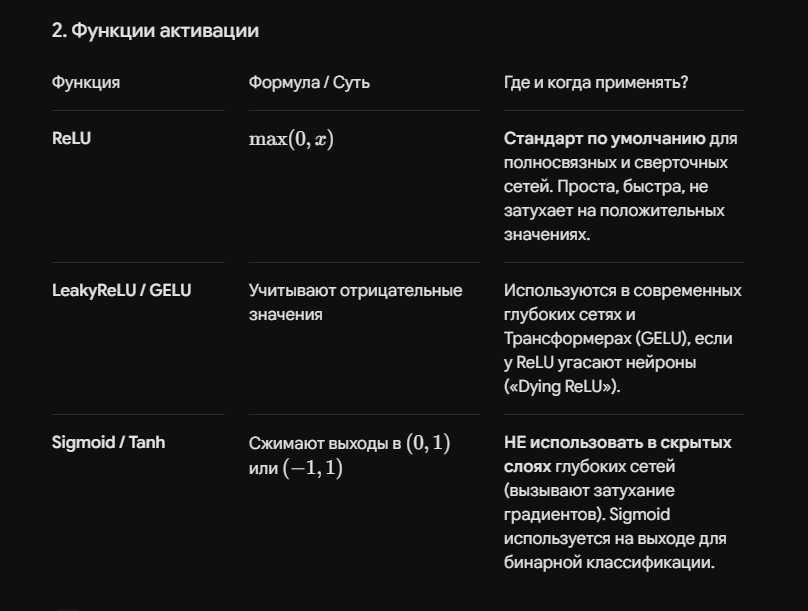

#### 3. Скорость обучения (Learning Rate, $\eta$)
Это самый важный гиперпараметр!
* Слишком большой ($lr = 0.1$): Градиентный спуск «перелетает» минимум, Loss начинает расти или превращается в NaN.
* Слишком маленький ($lr = 0.00001$): Сеть учится невероятно медленно и может застрять в локальном минимуме.
* Золотая середина для Adam: Диапазон от $10^{-4}$ до $10^{-3}$ (например, 0.001 или 0.0003).

### 📝 Практика 3.4: Эксперимент с поиском оптимального Learning Rate

**Условие:**
Проведи простой Random Search / Grid Search для подбора оптимального `learning rate` для модели `RegularizedMLP` на датасете Fashion-MNIST.

1. Задай список протестируемых значения learning rate: `lr_list = [0.1, 0.001, 0.00001]`.
2. Для каждого `lr` из списка:
   - Инициализируй модель `model = RegularizedMLP().to(device)`.
   - Создай оптимизатор `Adam` с текущим `lr`.
   - Обучи модель в течение всего **2 эпох**.
   - Посчитай `Test Accuracy` после 2 эпох обучения.
3. Выведи сравнение результатов для каждого `lr`.

> **Вопрос на самопроверку:** Какой `learning rate` показал себя хуже всего и почему? (Слишком большой приведет к осцилляциям/плохому качеству, слишком маленький — просто не успеет обучиться за 2 эпохи).

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Задаем корректную архитектуру RegularizedMLP
class RegularizedMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),

            # Блок 1
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            # Блок 2
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            # Выходной блок
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

# 2. Подготовка данных
my_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=my_transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=my_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
lr_list = [0.1, 0.001, 0.00001]
results = {}

# 3. Эксперимент с перебором Learning Rate
for lr in lr_list:
    print(f"=== Запуск обучения с learning_rate = {lr} ===")

    # Инициализация модели и оптимизатора заново для каждого lr
    model = RegularizedMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Цикл обучения на 2 эпохи
    for epoch in range(2):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Валидация на тестовой выборке
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()

    test_acc = (correct / len(test_loader.dataset)) * 100
    results[lr] = test_acc
    print(f"Результат за 2 эпохи для lr={lr}: Test Accuracy = {test_acc:.2f}%\n")

# 4. Итоговое сравнение
print("--- Итоговые результаты ---")
for lr, acc in results.items():
    print(f"LR: {lr:<7} | Test Accuracy: {acc:.2f}%")

=== Запуск обучения с learning_rate = 0.1 ===
Результат за 2 эпохи для lr=0.1: Test Accuracy = 84.15%

=== Запуск обучения с learning_rate = 0.001 ===
Результат за 2 эпохи для lr=0.001: Test Accuracy = 86.66%

=== Запуск обучения с learning_rate = 1e-05 ===
Результат за 2 эпохи для lr=1e-05: Test Accuracy = 77.90%

--- Итоговые результаты ---
LR: 0.1     | Test Accuracy: 84.15%
LR: 0.001   | Test Accuracy: 86.66%
LR: 1e-05   | Test Accuracy: 77.90%
